# Primary Pea · FAOSTAT EDA (clean)
Visuals-first pass across the four lenses · data vintages: TM/QCL **2024** · FS/CAHD **2025** · FBS **2023**

*Derived from the scratchpad (sharp-edges doc + full history live there). Fresh-runtime top-to-bottom safe.*

In [1]:
#! pip install faostat
# https://pypi.org/project/faostat/
! pip install --upgrade faostat

In [2]:
import faostat
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from google.colab import userdata as gcudata
import requests, time, re, os

#### Bootstrap

In [3]:
# @title ══════ Primary Pea · FAOSTAT bootstrap · v4 ════════════
# @markdown Cell 1 of every notebook. Safe to re-run any number of times.
#
# @markdown Canonical copy: notebooks/bootstrap_cell.py — edit there, re-paste here.
#
# v4 (2026-08-21): secret precedence now user+pass first — bearer tokens
#   expire 3600 s after issue, so stored tokens go stale; token mode
#   prints a caveat.
# v3 (2026-08-20): TM guidance corrected (reporter coverage, not API
#   truncation); once-per-session notice on TM fetches.
# v2 (2026-08-20): censored-value parsing, projection-year tripwire,
#   fetch_chunked for large pulls.
### ! ## %pip install -q faostat==2.0.1 pandas pyarrow

# import os, time, pandas as pd, faostat # already installed
from importlib.metadata import version as _pkg_version

BOOTSTRAP_VERSION = "4"
assert _pkg_version("faostat") == "2.0.1", (
    f"faostat {_pkg_version('faostat')} installed, need exactly 2.0.1 — "
    "the URL guard below targets 2.0.1 behavior. Re-run the %pip line "
    "above, then restart the runtime."
)

# ── auth (re-run-safe) ─────────────────────────────────────────────────
# faostat 2.0.1 bug (faostat.py line 53): set_requests_args() APPENDS
# 'en/' to the module-level __BASE_URL__ on EVERY call → re-runs 404.
# Resetting the base URL first makes auth idempotent and repairs an
# already-corrupted kernel without a restart.
# Credential precedence: explicit argument → FAOSTAT_USER+FAOSTAT_PASS →
# FAOSTAT_TOKEN. User+pass is preferred: the login happens fresh every
# session, while bearer tokens expire 3600 s after issue (login
# ExpiresIn, verified 2026-08-21) — a stored token goes stale within
# the hour and token mode gets no server validation at auth time.
# Always auth via faostat_auth(); never call set_requests_args directly.
_FAOSTAT_BASE = "https://faostatservices.fao.org/api/v1/"
_THIS_YEAR = 2026            # tripwire threshold for projection years

def _secret(name):
    """Env var, else Colab Secrets (🔑 panel — grant this notebook access)."""
    if os.environ.get(name):
        return os.environ[name]
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return None

def faostat_auth(token=None, username=None, password=None):
    faostat.faostat.__BASE_URL__ = _FAOSTAT_BASE          # ← the guard
    token_explicit = token is not None
    username = username or _secret("FAOSTAT_USER")
    password = password or _secret("FAOSTAT_PASS")
    token = token or _secret("FAOSTAT_TOKEN")
    if token_explicit or (token and not (username and password)):
        faostat.set_requests_args(token=token)
        print("⚠ token mode: FAOSTAT bearer tokens expire 3600 s after "
              "issue, so a stored FAOSTAT_TOKEN goes stale within the "
              "hour. Prefer FAOSTAT_USER + FAOSTAT_PASS — the bootstrap "
              "logs in fresh every session.")
    elif username and password:
        faostat.set_requests_args(username=username, password=password)
    else:
        raise RuntimeError(
            "No FAOSTAT credentials found. Set FAOSTAT_USER + "
            "FAOSTAT_PASS (preferred), or FAOSTAT_TOKEN, as env vars or "
            "Colab Secrets. Never paste credentials into a cell — this "
            "repo flips public after Sep 15."
        )
    assert faostat.faostat.__BASE_URL__ == _FAOSTAT_BASE + "en/", "base URL corrupted"
    print(f"FAOSTAT auth OK · base={faostat.faostat.__BASE_URL__} · bootstrap v{BOOTSTRAP_VERSION}")

# ── per-domain notices (visibility, never judgment) ────────────────────
# Printed once per session on first fetch of that domain.
_DOMAIN_NOTES = {
    "TM": ("TM is reporter-declared flows only — absent reporters are not "
           "zero, and summing reporters undercounts world totals. "
           "Sanity-check aggregates against an external benchmark; see "
           "README › FAOSTAT sharp edges for mirror-flow recovery."),
}
_noted = set()

# ── typed fetch ────────────────────────────────────────────────────────
# get_data_df() returns every column as str; casts are explicit so dtypes
# match on all five machines. Data handling (eda findings, 2026-08-20):
#   • censored values like '<2.5' (FS PoU floor): numeric part kept, the
#     bound recorded in Value_bound ('<' or '>') — label these on charts.
#   • range years like '2019-2021' (FS 3-yr averages): Year → <NA>, the
#     original labels kept in Year_raw.
#   • projection years (emissions domains mix 2030/2050 into observed
#     series): a warning prints — filter (e.g. Year <= 2023) before
#     charting. fetch_df never drops rows for you.
def fetch_df(code, pars=None, **kwargs):
    """faostat.get_data_df + dtype fixes: Value→float64, Year→Int64."""
    if code in _DOMAIN_NOTES and code not in _noted:
        print("ℹ " + _DOMAIN_NOTES[code])
        _noted.add(code)
    df = faostat.get_data_df(code, pars=pars or {}, **kwargs)
    if "Value" in df.columns:
        raw = df["Value"].astype("string")
        bound = raw.str.extract(r"^\s*([<>])", expand=False)
        if bound.notna().any():
            df["Value_bound"] = bound
        num = pd.to_numeric(raw.str.replace(r"^\s*[<>]\s*", "", regex=True),
                            errors="coerce")
        if (num.isna() & raw.notna()).any():
            df["Value_raw"] = raw        # coercion lost something — keep it
        df["Value"] = num
    if "Year" in df.columns:
        _year = pd.to_numeric(df["Year"], errors="coerce")
        if (_year.isna() & df["Year"].notna()).any():
            df["Year_raw"] = df["Year"]  # e.g. '2019-2021' range labels
        df["Year"] = _year.astype("Int64")
        _mx = df["Year"].max()
        if pd.notna(_mx) and _mx > _THIS_YEAR:
            print(f"⚠ Year values up to {_mx} — projection years present. "
                  "Filter (e.g. Year <= 2023) before charting observed series.")
    return df

# ── chunked fetch for large pulls ──────────────────────────────────────
# For genuinely large requests (multi-item / multi-year), chunk the heavy
# dimension and retry transient failures. NOTE: chunking is politeness
# and robustness, not completeness — a full-reporter chunked TM pull
# returns exactly the unfiltered result (verified 2026-08-20). TM gaps
# are reporter coverage; see README.
def fetch_chunked(code, dim, dim_codes, pars=None, chunk=25, retries=3, **kwargs):
    """fetch_df over dim_codes split into chunks of `chunk` on dimension `dim`."""
    out, codes = [], list(dim_codes)
    for i in range(0, len(codes), chunk):
        part = {**(pars or {}), dim: codes[i:i + chunk]}
        for attempt in range(retries):
            try:
                out.append(fetch_df(code, pars=part, **kwargs))
                break
            except Exception:
                if attempt == retries - 1:
                    raise
                time.sleep(2 ** attempt)
        print(f"  fetch_chunked: {min(i + chunk, len(codes))}/{len(codes)} "
              f"{dim} codes · {sum(len(d) for d in out)} rows")
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

faostat_auth()

FAOSTAT auth OK · base=https://faostatservices.fao.org/api/v1/en/ · bootstrap v4


#### Helper Functions

In [4]:
def prettifyObj(obj, indent=2, curDepth=0, maxDepth=None):
    if not isinstance(curDepth, int) or curDepth<0: curDepth = 0
    if not isinstance(indent, str):
        indent = ' '*(indent if isinstance(indent, int) and indent>0 else 2)
    if not indent or (isinstance(maxDepth, int) and not curDepth<maxDepth):
        return repr(obj)
    if not (obj and isinstance(obj, (list,set,tuple,dict))): return repr(obj)

    if isinstance(obj, dict):
        b1, b2 = '{', '}'
        unbraced = [(
            f'{indent*(curDepth+1)}{repr(k)}: ' +
            prettifyObj(v, indent, curDepth+1, maxDepth).strip()
        ) for k, v in obj.items()]
    else:
        if isinstance(obj, list): b1, b2 = '[', ']'
        elif isinstance(obj, set): b1, b2 = '{', '}'
        elif isinstance(obj, tuple): b1, b2 = '(', ')'
        unbraced = [(
            indent*(curDepth+1) +
            prettifyObj(v, indent, curDepth+1, maxDepth).strip()
        ) for v in obj]

    b1, b2 = f'{indent*curDepth}{b1}\n', f'\n{indent*curDepth}{b2}'

    return b1 + ',\n'.join(unbraced) + b2

In [5]:
def prettyPrint(obj, pFunc=prettifyObj, *pargs, **pwargs):
    print(pFunc(obj, *pargs, **pwargs))

In [6]:
def print_attrs(o):
    for a,ta,av in [(k,type(getattr(o,k)),getattr(o,k)) for k in dir(o)]:
        if callable(av):
            try: av = av()
            except: continue
        print(f'{a:>15} : {ta} --> {type(av)} {miniStr(repr(av))}')

In [7]:
def stripStr(str): return ' '.join(c for c in str.split() if c)
def truncateIfLong(str, maxLen=45):
    if type(maxLen) != int: maxLen = 15
    if maxLen < 4: maxLen = 5
    return str if len(str) < maxLen else str[:maxLen-3]+'...'

def miniStr(obj, lineSep=' ', wordSep=' ', trunc=None):
  mStr = lineSep.join(
      wordSep.join(w for w in l.split() if w)
      for l in str(obj).splitlines() if l.strip()
  )
  return truncateIfLong(mStr, trunc) if trunc else mStr

In [8]:
def reqStatus(r, isv=False, toRet=None):
    sc = r.reason or ('OK' if r.status_code==200 else '???')
    rs = f'<Response [{r.status_code} {sc}]> in {r.elapsed} from {r.url}'
    if isv: return (print(rs), r if toRet is None else toRet)[1]
    return rs

In [9]:
def world_code(domain):
    a = faostat.get_par_df(domain, 'area')
    w = a[a['label'].str.contains('World', case=False)]
    w = w[~w['code'].astype(str).str.contains('>')]
    return w['code'].iloc[0]

def year_x(tok):                    # '2024' -> 2024 ; '2022-2024' -> 2023
    ys = [int(y) for y in re.findall(r'\d{4}', str(tok))]
    return sum(ys) // len(ys)

def leaf_labels(domain, par='area'):
    p = faostat.get_par_df(domain, par)
    return set(p.loc[p['aggregate_type'].astype(str) == '0', 'label'])

---
## Catalog
*Latest year per domain we touch — FBS's next release lands after submission.*

In [10]:
ds = faostat.list_datasets_df()
print(ds[ds['code'].isin(['FBS','FS','CAHD','TM','QCL','GT'])]
        [['code','label','year_current','release_current','release_next']]
        .to_string(index=False))

code                                            label year_current release_current release_next
 QCL                     Crops and livestock products         2024      2025-12-31      2026-12
  FS                Suite of Food Security Indicators         2025      2026-07-21      2027-07
 FBS                            Food Balances (2010-)         2023      2025-10-28      2026-10
  TM                            Detailed trade matrix         2024      2025-12-23      2026-12
CAHD Cost and Affordability of a Healthy Diet (CoAHD)         2025      2026-07-21      2026-12
  GT                                 Emissions totals         2023      2025-10-28      2026-10


---
## World · supply rose, access stumbled
*kcal/cap climbed monotonically through the exact window (2019–22) where undernourishment rebounded and food insecurity peaked (~29 %, 2020).*

In [11]:
fbs = faostat.get_data_df('FBS', pars={'area': [5000], 'area_cs': 'M49'})
f = fbs.copy()
f['Value'] = pd.to_numeric(f['Value'], errors='coerce')
f['Year']  = f['Year'].astype(int)

fsw = faostat.get_data_df('FS', pars={'area': [world_code('FS')],
                                      'item': [21004, 21009]})   # year3 omitted on purpose
fsw['Value'] = pd.to_numeric(fsw['Value'], errors='coerce')

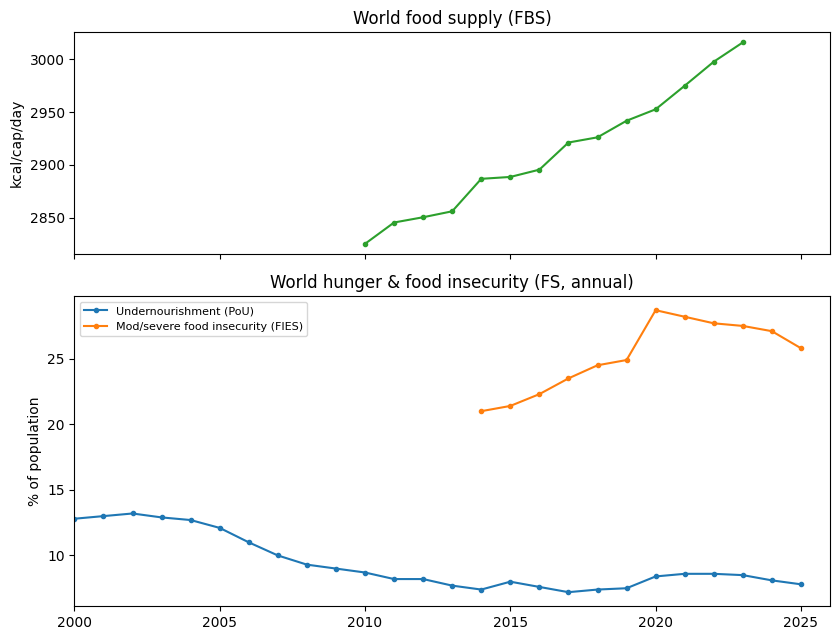

In [12]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.5, 6.5), sharex=True,
                             gridspec_kw={'height_ratios': [1, 1.4]})
des = f[(f['Item'] == 'Grand Total') &
        (f['Element'] == 'Food supply (kcal/capita/day)')].sort_values('Year')
a1.plot(des['Year'], des['Value'], marker='.', color='tab:green')
a1.set_ylabel('kcal/cap/day'); a1.set_title('World food supply (FBS)')

w = fsw[(fsw['Element'] == 'Value') &
        (fsw['Item Code'].astype(str).isin(['210040', '210090'])) &      # annual, total pop
        (fsw['Year'].astype(str).str.fullmatch(r'\d{4}'))].copy()
w['x'] = w['Year'].astype(int)
for code, g in w.groupby('Item Code'):
    lab = ('Undernourishment (PoU)' if str(code) == '210040'
           else 'Mod/severe food insecurity (FIES)')
    g = g.sort_values('x'); a2.plot(g['x'], g['Value'], marker='.', label=lab)
a2.set_ylabel('% of population'); a2.legend(fontsize=8)
a2.set_title('World hunger & food insecurity (FS, annual)')
a2.set_xlim(2000, 2026)
plt.tight_layout(); plt.show()

---
## Eat · affordability vs hunger (n≈152 countries)
*The story is the residuals: Haiti 89 %/51 %; Bolivia affordable-but-hungry (11 %/20 %); Somalia is hungriest (PoU 56.5 %) but has no CAHD value, so the worst case can't appear here. PoU is 3-yr avg, mixed vintages, `<2.5` floored.*

In [13]:
cahd = faostat.get_data_df('CAHD', pars={'element': [6120], 'item': [7005]})
cahd['Value'] = pd.to_numeric(cahd['Value'], errors='coerce')
latest = str(max(cahd['Year'].astype(str)))
leafFS = leaf_labels('FS')
pua = cahd[(cahd['Year'].astype(str) == latest) & cahd['Area'].isin(leafFS)]

fs2 = faostat.get_data_df('FS', pars={'item': [21004]})
fs2['Value'] = pd.to_numeric(fs2['Value'].astype(str).str.replace('<', '', regex=False),
                             errors='coerce')                    # '<2.5' -> floor 2.5
pou = fs2[(fs2['Element'] == 'Value') & fs2['Area'].isin(leafFS)].dropna(subset=['Value']).copy()
pou['x'] = pou['Year'].map(year_x)
pou = pou.sort_values('x').groupby('Area', as_index=False).last()
m = pua.merge(pou, on='Area', suffixes=('_pua', '_pou'))
print('countries merged:', len(m))

countries merged: 152


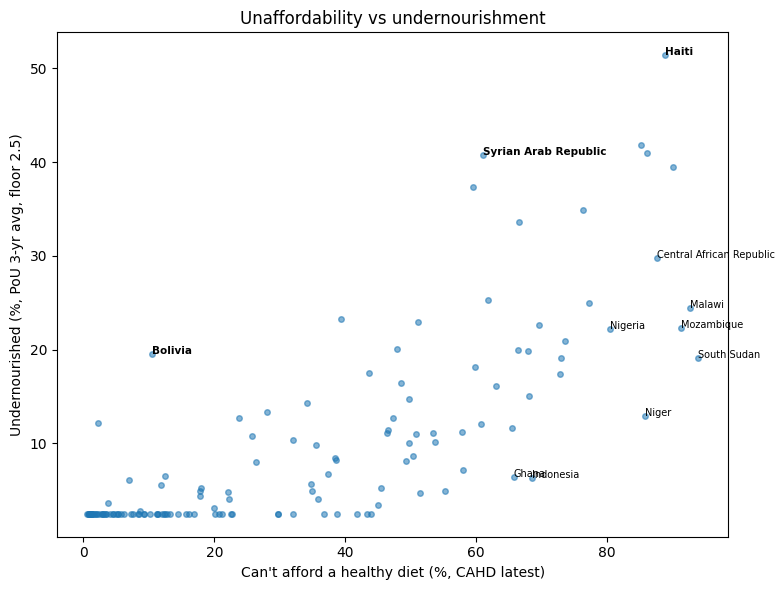

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m['Value_pua'], m['Value_pou'], s=16, alpha=0.55)
for i in (m['Value_pou'] - m['Value_pua']).abs().nlargest(8).index:
    ax.annotate(m.loc[i, 'Area'], (m.loc[i, 'Value_pua'], m.loc[i, 'Value_pou']), fontsize=7)
for name in ['Haiti', 'Bolivia (Plurinational State of)', 'Syrian Arab Republic']:
    r = m[m['Area'] == name]
    if len(r):
        ax.annotate(name.split(' (')[0],
                    (r['Value_pua'].iloc[0], r['Value_pou'].iloc[0]),
                    fontsize=7.5, fontweight='bold')
ax.set_xlabel("Can't afford a healthy diet (%, CAHD latest)")
ax.set_ylabel('Undernourished (%, PoU 3-yr avg, floor 2.5)')
ax.set_title('Unaffordability vs undernourishment')
plt.tight_layout(); plt.show()

---
## Sustain · agrifood ≈ ⅓ of global emissions
*Additive trio checks exactly; the post-farm chain out-emits all land-use change. GT mixes projection years (2030/2050) into observed series — filtered here.*

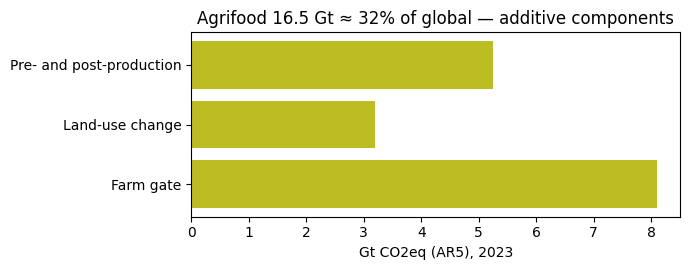

In [15]:
gt = faostat.get_data_df('GT', pars={'area': [world_code('GT')]})
gt['Value'] = pd.to_numeric(gt['Value'], errors='coerce')
g = gt[(gt['Element'] == 'Emissions (CO2eq) (AR5)') &
       (pd.to_numeric(gt['Year'], errors='coerce') <= 2023)].copy()
yr = g['Year'].astype(int).max()
g = g[g['Year'].astype(int) == yr]
tot = g.loc[g['Item'] == 'All sectors with LULUCF', 'Value'].iloc[0]
af  = g.loc[g['Item'] == 'Agrifood systems', 'Value'].iloc[0]
trio = g[g['Item'].isin(['Farm gate', 'Pre- and post-production', 'Land-use change'])]
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(trio['Item'], trio['Value'] / 1e6, color='tab:olive')
ax.set_xlabel(f'Gt CO2eq (AR5), {yr}')
ax.set_title(f'Agrifood {af/1e6:.1f} Gt ≈ {af/tot:.0%} of global — additive components')
plt.tight_layout(); plt.show()

---
## Trade · wheat majors with one dominant supplier (2024)
*Reported flows only: TM is reporter-declared — Algeria & Bangladesh (major importers) are absent as reporters, verified as coverage, not query loss. Threshold ≥1 Mt keeps it to majors.*

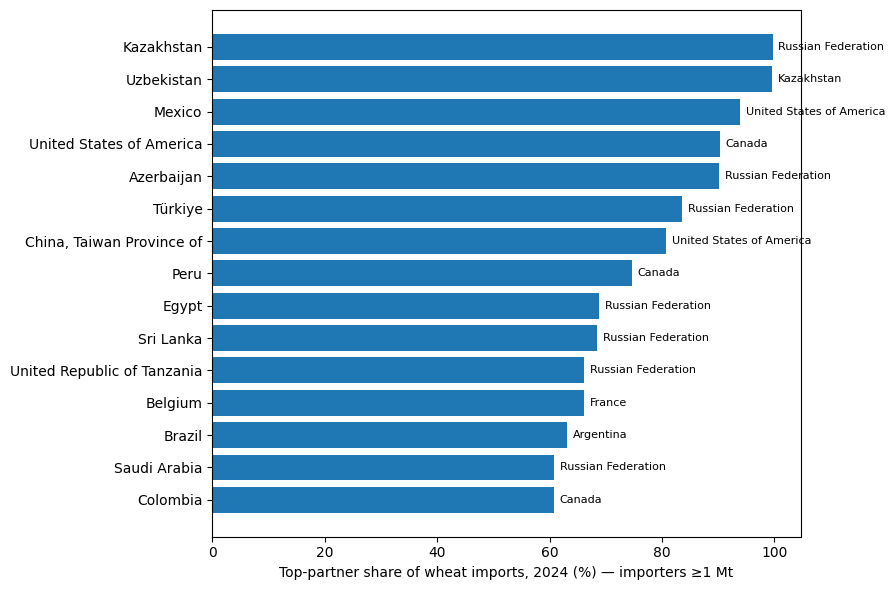

In [16]:
tm = faostat.get_data_df('TM', pars={'element': [2610],   # Import quantity
                                     'item': [15],        # Wheat
                                     'year': [2024]})
tm['Value'] = pd.to_numeric(tm['Value'], errors='coerce')
tm = tm[tm['Partner Countries'].isin(leaf_labels('TM', 'partnerarea')) & (tm['Value'] > 0)]
conc = (tm.groupby('Reporter Countries')['Value']
          .agg(total_t='sum', top_t='max', n_partners='count'))
conc['top_share'] = conc['top_t'] / conc['total_t']
idx = tm.groupby('Reporter Countries')['Value'].idxmax()
conc['top_partner'] = tm.loc[idx].set_index('Reporter Countries')['Partner Countries']
sig = conc[conc['total_t'] >= 1e6].sort_values('top_share', ascending=False)
top15 = sig.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index, top15['top_share'] * 100)
for y, (shr, prt) in enumerate(zip(top15['top_share'], top15['top_partner'])):
    ax.text(shr * 100 + 1, y, prt, va='center', fontsize=8)
ax.set_xlabel('Top-partner share of wheat imports, 2024 (%) — importers ≥1 Mt')
plt.tight_layout(); plt.show()

---
## Eat/Grow · what the world fries in, 2010→2023
*Added-fat kcal consolidated into palm + sunflower while four traditional oils fell.*

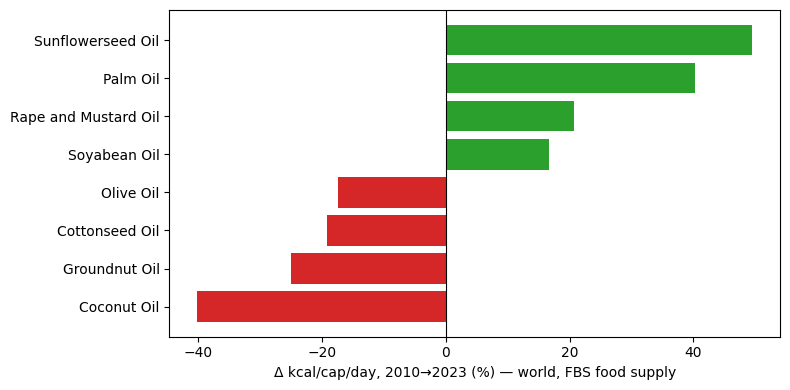

In [17]:
oils = ['Palm Oil', 'Sunflowerseed Oil', 'Soyabean Oil', 'Rape and Mustard Oil',
        'Olive Oil', 'Cottonseed Oil', 'Groundnut Oil', 'Coconut Oil']
e = f[(f['Element'] == 'Food supply (kcal/capita/day)') &
      f['Item'].isin(oils) & f['Year'].isin([2010, 2023])]
p = e.pivot_table(index='Item', columns='Year', values='Value', aggfunc='first').dropna()
p['pct'] = (p[2023] / p[2010] - 1) * 100
p = p.sort_values('pct')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(p.index, p['pct'], color=['tab:red' if v < 0 else 'tab:green' for v in p['pct']])
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Δ kcal/cap/day, 2010→2023 (%) — world, FBS food supply')
plt.tight_layout(); plt.show()

---
## Mascot corner · pea supply
*FBS food **supply** = availability, not intake. Norway tops full-coverage countries at ~12.5 kg/cap/yr.*

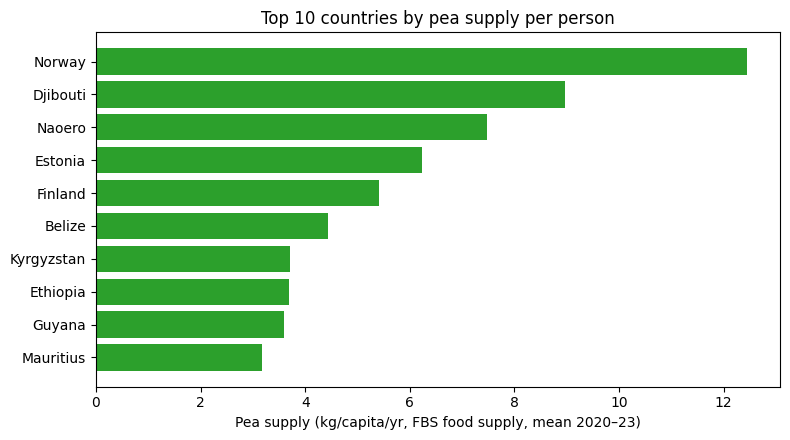

In [18]:
peas = faostat.get_data_df('FBS', pars={'element': [645], 'item': [2547],
                                        'year': [2020, 2021, 2022, 2023]})
peas['Value'] = pd.to_numeric(peas['Value'], errors='coerce')
peas = peas[peas['Area'].isin(leaf_labels('FBS'))]
pea = (peas.groupby('Area')['Value']
            .agg(mean_kg_cap_yr='mean', years='count')
            .sort_values('mean_kg_cap_yr', ascending=False).reset_index())
top = pea[pea['years'] == 4].head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top['Area'], top['mean_kg_cap_yr'], color='tab:green')
ax.set_xlabel('Pea supply (kg/capita/yr, FBS food supply, mean 2020–23)')
ax.set_title('Top 10 countries by pea supply per person')
plt.tight_layout(); plt.show()

---
## Appendix · world movers tables (orientation-grade)

In [19]:
pd.set_option('display.width', 160)

if 'fbs' not in globals():
    fbs = faostat.get_data_df('FBS', pars={'area': [5000], 'area_cs': 'M49'})

f = fbs.copy()
f['Value'] = pd.to_numeric(f['Value'], errors='coerce')
f['Year']  = f['Year'].astype(int)

# NB: FBS aggregate rows (Grand Total, Vegetal/Animal Products, Cereals, ...)
# appear alongside leaf items
# [informative for orientation, just read accordingly]
def movers(element, first=2010, last=2023, floor_q=0.25, n=10):
    e = f[(f['Element'] == element) & (f['Year'].isin([first, last]))]
    p = e.pivot_table(
        index='Item', columns='Year', values='Value', aggfunc='first'
    ).dropna()
    p.columns = ['y2010', 'y2023']

    p = p[p['y2010'] > p['y2010'].quantile(floor_q)]
    # tiny bases make Δ% explode
    p['pct']  = (p['y2023'] / p['y2010'] - 1) * 100
    p['unit'] = e['Unit'].iloc[0]
    p = p.sort_values('pct', ascending=False)
    print(f"\n===== {element} — 2010→2023 =====")
    print("--- risers ---");  print(p.head(n).round(1).to_string())
    print("--- fallers ---"); print(p.tail(n).round(1).to_string())

In [20]:
for el in ['Production', 'Import quantity', 'Export quantity',
           'Food supply (kcal/capita/day)',
           'Protein supply quantity (g/capita/day)']:
    movers(el)


===== Production — 2010→2023 =====
--- risers ---
                              y2010    y2023    pct    unit
Item                                                       
Tea (including mate)        11956.0  33800.0  182.7  1000 t
Stimulants                  24751.0  50544.0  104.2  1000 t
Sunflower seed              31456.0  58572.0   86.2  1000 t
Sunflowerseed Oil           12512.0  22605.0   80.7  1000 t
Roots, Other                15610.0  27812.0   78.2  1000 t
Palm Oil                    45749.0  79678.0   74.2  1000 t
Aquatic Products, Other     21270.0  36354.0   70.9  1000 t
Aquatic Plants              21270.0  36354.0   70.9  1000 t
Lemons, Limes and products  14460.0  23708.0   64.0  1000 t
Yams                        56366.0  89079.0   58.0  1000 t
--- fallers ---
                                 y2010     y2023  pct    unit
Item                                                         
Alcoholic Beverages           271351.0  278936.0  2.8  1000 t
Olives (including preserved

---
## Workbench · nearshoring-gaps poke — **UNRUN**
*Idea: who imports wheat mostly from outside their own subregion, while that subregion supplies wheat at scale? Subregion = distance proxy (v1); flows are reported-only; a flow's existence ≠ price/quality feasibility. Upgrades if it survives: CEPII bilateral distances; GAEZ suitability for the 'could grow it themselves' half.*

In [21]:
! pip install country_converter -q
import logging
import country_converter as coco
logging.getLogger('country_converter.country_converter').setLevel(logging.ERROR)
cc = coco.CountryConverter()

imp = tm.copy()                                   # wheat 2024, leaf partners, from Trade section

OVERRIDES = {'Naoero': 'Nauru',                   # FAOSTAT spellings coco misses / multi-matches
             'China, Taiwan Province of': 'Taiwan'}
names  = sorted(set(imp['Reporter Countries']) | set(imp['Partner Countries']))
lookup = [OVERRIDES.get(n, n) for n in names]
conv   = cc.convert(names=lookup, to='UNregion', not_found='__MISS__')

def norm(v):                                      # coco returns a LIST on multi-match
    if isinstance(v, list):
        v = sorted(set(v))
        return v[0] if len(v) == 1 else '__AMBIG__:' + '/'.join(v)
    return v

sub = {n: norm(v) for n, v in zip(names, conv)}
bad = {n: v for n, v in sub.items() if str(v).startswith('__')}
print('unmapped / ambiguous:', bad or 'none')

imp['rep_sub'] = imp['Reporter Countries'].map(sub)
imp['par_sub'] = imp['Partner Countries'].map(sub)
imp = imp[~imp['rep_sub'].astype(str).str.startswith('__') &
          ~imp['par_sub'].astype(str).str.startswith('__')]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 4.2 MB/s eta 0:00:00
unmapped / ambiguous: none


In [22]:
tot   = imp.groupby('Reporter Countries')['Value'].sum()
intra = (imp[imp['rep_sub'] == imp['par_sub']]
         .groupby('Reporter Countries')['Value'].sum())
gaps = pd.DataFrame({'total_t': tot, 'intra_t': intra}).fillna(0)
gaps['intra_share'] = gaps['intra_t'] / gaps['total_t']
gaps['sub'] = gaps.index.map(lambda n: sub.get(n))

cap = imp.groupby('par_sub')['Value'].sum() / 1e6   # Mt each subregion supplies (partner side)
print('\nwheat supplied BY subregion (Mt, reported):'); print(cap.round(1).to_string())

big = gaps[gaps['total_t'] >= 1e6].sort_values('intra_share')
big['sub_capacity_Mt'] = big['sub'].map(cap).round(1)
print('\nmajors sourcing least from their own subregion:')
print(big.head(15).round(3).to_string())


wheat supplied BY subregion (Mt, reported):
par_sub
Australia and New Zealand    15.1
Caribbean                     0.0
Central America               0.0
Central Asia                  6.0
Eastern Africa                0.1
Eastern Asia                  0.2
Eastern Europe               62.9
Middle Africa                 0.0
Northern Africa               0.0
Northern America             38.1
Northern Europe               4.5
Polynesia                     0.0
South America                10.2
South-eastern Asia            0.0
Southern Africa               0.3
Southern Asia                 0.0
Southern Europe               2.8
Western Africa                0.0
Western Asia                  1.2
Western Europe               20.4

majors sourcing least from their own subregion:
                                 total_t  intra_t  intra_share                 sub  sub_capacity_Mt
Reporter Countries                                                                                 
China, mainland   

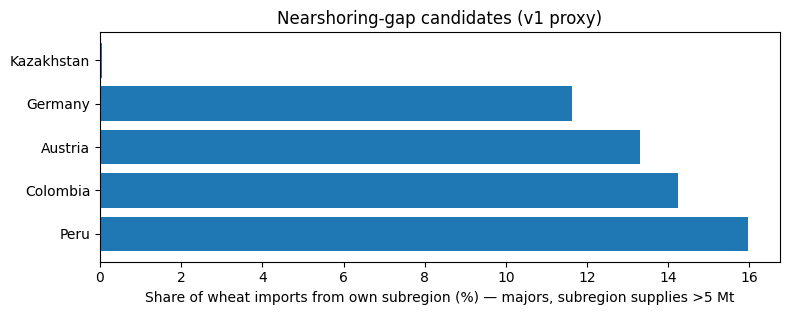

In [23]:
cand = big[(big['intra_share'] < 0.25) & (big['sub_capacity_Mt'] > 5)]
fig, ax = plt.subplots(figsize=(8, 0.45 * max(len(cand), 4) + 1))
ax.barh(cand.index[::-1], cand['intra_share'][::-1] * 100)
ax.set_xlabel('Share of wheat imports from own subregion (%) — majors, subregion supplies >5 Mt')
ax.set_title('Nearshoring-gap candidates (v1 proxy)')
plt.tight_layout(); plt.show()